<a href="https://colab.research.google.com/github/aljubic1/bioinformatika_projekt_alj/blob/main/notebooks/01_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

01_data_preparation.ipynb

1. Naslov i cilj
2. Uvoz biblioteka
3. Učitavanje podataka
4. Osnovni pregled podataka
5. Provjera nedostajućih vrijednosti
6. Filtriranje monomera
7. Čišćenje sekvenci
8. Dodavanje label = 1
9. Spremanje u data/processed/
10. Zaključak

# 01. Data Preparation

## Cilj

Cilj ovog dijela projekta je učitati peptidne sekvence iz baze DBAASP, provjeriti njihovu kvalitetu te pripremiti skup podataka za daljnju bioinformatičku analizu. Tijekom pripreme podataka uklanjaju se neispravni zapisi, filtriraju monomerni peptidi, provjerava valjanost aminokiselinskih sekvenci te se formira očišćeni skup podataka koji će se koristiti u sljedećim fazama projekta.

In [5]:
import sys

sys.path.append("/content/src")

from data_utils import (
    load_dataset,
    check_required_columns,
    print_dataset_info,
    check_missing_values,
    filter_monomers,
    clean_sequences,
    add_label,
    save_processed_dataset
)

In [6]:
# Putanja do sirovih podataka.
raw_data_path = "/content/peptides.csv"

# Učitavanje podataka.
df = load_dataset(raw_data_path)

# Prikaz prvih pet redaka.
df.head()

,ID,COMPLEXITY,NAME,N TERMINUS,SEQUENCE,C TERMINUS,SYNTHESIS TYPE,TARGET GROUP,TARGET OBJECT
0,1,Multimer,Distinctin,NaN,NLVSGLIEARKYLEQLHRKLKNCKV ENREVPPGFTALIKTLR...,NaN,Ribosomal,Gram+ Gram-,Lipid Bilayer
1,3,Multimer,Halocidin,NaN,WLNALLHHGLNCAKGVLA ALLHHGLNCAKGVLA,AMD AMD,Ribosomal,Gram+,Lipid Bilayer
2,4,Multimer,Khal,NaN,KWLNALLHHGLNCAKGVLA ALLHHGLNCAKGVLA,AMD AMD,Synthetic,Gram+ Gram-,Lipid Bilayer
3,6,Multi-Peptide,Enterocin X,NaN,SNDSLWYGVGQFMGKQANCITNHPVKHMIIPGYCLSKILG IA...,NaN,Ribosomal,Gram+,Lipid Bilayer
4,7,Multi-Peptide,EAFP1 + EAFP2,NaN,XTCASRCPRPCNAGLCCSIYGYCGSGNAYCGAGNCRCQCRG X...,NaN,Ribosomal,Fungus,Lipid Bilayer


In [7]:
# Zadržavanje samo monomernih peptida.
df_monomer = filter_monomers(df)

# Prikaz dimenzija nakon filtriranja.
print(df_monomer.shape)

# Prikaz prvih pet redaka.
df_monomer.head()

(1976, 9)


,ID,COMPLEXITY,NAME,N TERMINUS,SEQUENCE,C TERMINUS,SYNTHESIS TYPE,TARGET GROUP,TARGET OBJECT
0,8,Monomer,NaN,C16,KVvvKWVvKvVK,AMD,Synthetic,Gram+ Gram- Fungus,Lipid Bilayer
1,10,Monomer,NaN,NaN,LFIFFF,AMD,Synthetic,Gram+,Lipid Bilayer
2,11,Monomer,"Cathelicidin-1, CATH-1, Fowlicidin-1",NaN,RVKRVWPLVIRTVIAGYNLYRAIKKK,NaN,Ribosomal,Gram+ Gram- Cancer Mammalian Cell,Lipid Bilayer
3,12,Monomer,NaN,NaN,RKRIHIGPGRAFYTT,NaN,Synthetic,Gram+ Gram-,Lipid Bilayer
4,13,Monomer,RNal,ACT,RRXXRF,AMD,Synthetic,Gram+ Gram-,Lipid Bilayer


In [8]:
# Čišćenje sekvenci.
df_clean = clean_sequences(df_monomer)

# Ispis dimenzija nakon čišćenja.
print(df_clean.shape)

# Prikaz prvih pet redaka.
df_clean.head()

(1672, 9)


,ID,COMPLEXITY,NAME,N TERMINUS,SEQUENCE,C TERMINUS,SYNTHESIS TYPE,TARGET GROUP,TARGET OBJECT
0,8,Monomer,NaN,C16,KVVVKWVVKVVK,AMD,Synthetic,Gram+ Gram- Fungus,Lipid Bilayer
1,10,Monomer,NaN,NaN,LFIFFF,AMD,Synthetic,Gram+,Lipid Bilayer
2,11,Monomer,"Cathelicidin-1, CATH-1, Fowlicidin-1",NaN,RVKRVWPLVIRTVIAGYNLYRAIKKK,NaN,Ribosomal,Gram+ Gram- Cancer Mammalian Cell,Lipid Bilayer
3,12,Monomer,NaN,NaN,RKRIHIGPGRAFYTT,NaN,Synthetic,Gram+ Gram-,Lipid Bilayer
4,14,Monomer,Brevinin-2 related peptide B2RP,NaN,GIWDTIKSMGKVFAGKILQNL,AMD,Ribosomal,Gram+ Gram- Virus Fungus Mammalian...,Lipid Bilayer Virus replication


In [9]:
# Dodavanje oznake da se radi o antimikrobnim peptidima.
df_clean = add_label(df_clean, label=1)

# Prikaz prvih pet redaka.
df_clean.head()

,ID,COMPLEXITY,NAME,N TERMINUS,SEQUENCE,C TERMINUS,SYNTHESIS TYPE,TARGET GROUP,TARGET OBJECT,label
0,8,Monomer,NaN,C16,KVVVKWVVKVVK,AMD,Synthetic,Gram+ Gram- Fungus,Lipid Bilayer,1
1,10,Monomer,NaN,NaN,LFIFFF,AMD,Synthetic,Gram+,Lipid Bilayer,1
2,11,Monomer,"Cathelicidin-1, CATH-1, Fowlicidin-1",NaN,RVKRVWPLVIRTVIAGYNLYRAIKKK,NaN,Ribosomal,Gram+ Gram- Cancer Mammalian Cell,Lipid Bilayer,1
3,12,Monomer,NaN,NaN,RKRIHIGPGRAFYTT,NaN,Synthetic,Gram+ Gram-,Lipid Bilayer,1
4,14,Monomer,Brevinin-2 related peptide B2RP,NaN,GIWDTIKSMGKVFAGKILQNL,AMD,Ribosomal,Gram+ Gram- Virus Fungus Mammalian...,Lipid Bilayer Virus replication,1


In [10]:
# Spremanje obrađenog skupa podataka.
save_processed_dataset(
    df_clean,
    "/content/amp_clean.csv"
)

In [11]:
import os

os.listdir("/content")

['.config',
 'amp_clean.csv',
 'peptides.csv',
 'data_utils.py',
 '__pycache__',
 'sample_data']

In [12]:
# Broj zapisa po tipu peptida.
df["COMPLEXITY"].value_counts()

,count
COMPLEXITY,
Monomer,1976
Multi-Peptide,21
Multimer,3


### Provjera nedostajućih vrijednosti

Prije daljnje obrade provjerene su nedostajuće vrijednosti u svim stupcima skupa podataka. Posebna pažnja posvećena je stupcu **SEQUENCE**, budući da predstavlja osnovu za izračun bioinformatičkih značajki. Rezultati pokazuju da stupac **SEQUENCE** ne sadrži nedostajuće vrijednosti, što omogućuje pouzdanu daljnju analizu. Nedostajuće vrijednosti u stupcima poput **NAME**, **N TERMINUS** i **C TERMINUS** nisu kritične jer se ti podaci ne koriste pri izračunu značajki niti tijekom treniranja modela.

In [13]:
# Provjera nedostajućih vrijednosti.
check_missing_values(df)

,0
ID,0
COMPLEXITY,0
NAME,309
N TERMINUS,1857
SEQUENCE,0
C TERMINUS,1075
SYNTHESIS TYPE,0
TARGET GROUP,17
TARGET OBJECT,111


Tijekom pripreme podataka zadržani su samo monomerni peptidi. Nakon toga provedena je provjera valjanosti sekvenci kako bi se uklonili zapisi koji sadrže nestandardne aminokiseline ili druge nepravilnosti. U završnom koraku uklonjeni su duplikati, čime je dobiven pouzdan skup podataka za daljnju analizu.

### Izvještaj o čišćenju podataka

Nakon filtriranja monomernih peptida provedena je provjera valjanosti sekvenci. Uklonjene su sekvence koje sadrže nestandardne aminokiseline ili druge nepravilnosti te su uklonjeni duplikati. Na kraju je dobiven konačni skup podataka koji će se koristiti za ekstrakciju značajki i treniranje modela strojnog učenja.

In [15]:
# Broj zapisa prije čišćenja.
before = len(df_monomer)

# Broj zapisa nakon čišćenja.
after = len(df_clean)

print("=" * 40)
print("IZVJEŠTAJ O ČIŠĆENJU PODATAKA")
print("=" * 40)
print(f"Monomeri prije čišćenja : {before}")
print(f"Monomeri nakon čišćenja : {after}")
print(f"Uklonjeno zapisa        : {before - after}")
print("=" * 40)

IZVJEŠTAJ O ČIŠĆENJU PODATAKA
Monomeri prije čišćenja : 1976
Monomeri nakon čišćenja : 1672
Uklonjeno zapisa        : 304


In [16]:
# Dodavanje stupca s duljinom svake peptidne sekvence.
df_clean["sequence_length"] = df_clean["SEQUENCE"].apply(len)

# Prikaz osnovne statistike duljina sekvenci.
df_clean["sequence_length"].describe()

,sequence_length
count,1672.000000
mean,21.490431
std,12.771008
min,1.000000
25%,13.000000
50%,19.000000
75%,26.000000
max,119.000000


### Raspodjela duljina peptidnih sekvenci

Analiza duljine sekvenci važna je jer antimikrobni peptidi najčešće predstavljaju kraće lance aminokiselina. Duljina sekvence može utjecati na sposobnost peptida da se veže za membranu mikroorganizma i ostvari antimikrobno djelovanje.

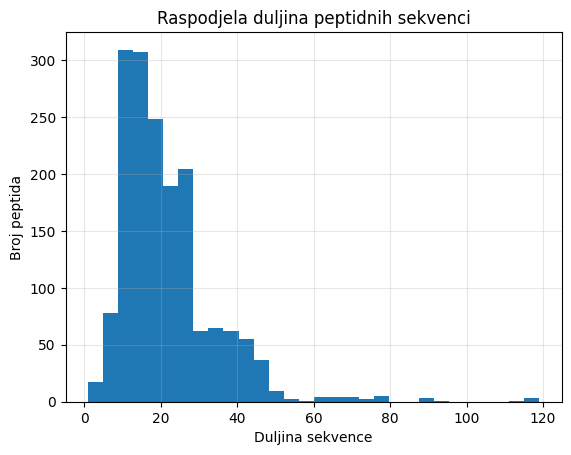

In [18]:
# Uvoz biblioteke za izradu grafova.
import matplotlib.pyplot as plt

# Izrada histograma duljina peptidnih sekvenci.
plt.hist(df_clean["sequence_length"], bins=30)

# Dodavanje naslova grafa.
plt.title("Raspodjela duljina peptidnih sekvenci")

# Oznaka x-osi.
plt.xlabel("Duljina sekvence")

# Oznaka y-osi.
plt.ylabel("Broj peptida")

# Dodavanje mreže radi lakšeg očitavanja vrijednosti.
plt.grid(alpha=0.3)

### Interpretacija rezultata

Histogram pokazuje da većina antimikrobnih peptida u analiziranom skupu ima duljinu između približno 10 i 30 aminokiselina. Prosječna duljina iznosi oko 21 aminokiselinu, što je u skladu s poznatim svojstvima antimikrobnih peptida. Uočava se i manji broj duljih peptida koji predstavljaju rijetke primjere unutar baze DBAASP.

In [19]:
#Broj zapisa kroz cjevovod
summary = {
    "Korak": [
        "Početni skup",
        "Monomeri",
        "Nakon čišćenja"
    ],
    "Broj zapisa": [
        len(df),
        len(df_monomer),
        len(df_clean)
    ]
}

import pandas as pd

pd.DataFrame(summary)

,Korak,Broj zapisa
0,Početni skup,2000
1,Monomeri,1976
2,Nakon čišćenja,1672
